# Visualizing results

In [3]:
import os
import numpy as np
import pandas as pd
import plotnine as pln

In [1]:
def read_results(res_dir_path, model_name):
    res = pd.DataFrame()
    for file in os.listdir(res_dir_path):
        if file.endswith('.csv'):
            dataset = file.split('.')[0]
            df = pd.read_csv(os.path.join(res_dir_path, file), index_col=0)
            df['dataset'] = dataset
            res = pd.concat([res, df], ignore_index=True)
    res['Model'] = model_name
    return res

# Viral x Non-viral proteins

In [3]:
prot_lengths = {}

# viral proteins
for prot in os.listdir('../data/viral/metadata/'):
    if prot.endswith('.csv'):
        df = pd.read_csv(os.path.join('../data/viral/metadata/', prot), index_col=0)
        prot_lengths[prot.split('.csv')[0]] = int(df['sequence'].apply(lambda x: len(x)).mean())

# non-viral proteins
for prot in os.listdir('../data/nonviral/metadata/'):
    if prot.endswith('.csv'):
        df = pd.read_csv(os.path.join('../data/nonviral/metadata/', prot), index_col=0)
        prot_lengths[prot.split('.csv')[0]] = int(df['sequence'].apply(lambda x: len(x)).mean())

In [4]:
cols = ['Fold', 'R2_score_train', 'MAE_score_train', 'RMSE_score_train',
       'R2_score_test', 'MAE_score_test', 'RMSE_score_test', 'rho_score_train',
       'rho_score_test', 'dataset', 'Model', 'Source']

In [5]:
res_full = pd.DataFrame()
for method in ['lassoCV', 'lassoCV_SS']:
  
    res_dir_path = f'../experiments/{method}/esmc_300m/viral'
    res_esmc_viral = read_results(res_dir_path, 'esmc_300m')
    res_esmc_viral['Source'] = 'Viral'

    res_dir_path = f'../experiments/{method}/esmc_300m/nonviral'
    res_esmc_nonviral = read_results(res_dir_path, 'esmc_300m')
    res_esmc_nonviral['Source'] = 'Non-viral'

    res = pd.concat([res_esmc_viral[cols], res_esmc_nonviral[cols]], ignore_index=True)
    
    if method == 'lassoCV':
        res['split_method'] = 'Random'
    elif method == 'lassoCV_SS':
        res['split_method'] = 'Site Split'
    res_full = pd.concat([res_full, res], ignore_index=True)


res_full['prot_length'] = res_full['dataset'].map(prot_lengths)
res_full

,Fold,R2_score_train,MAE_score_train,RMSE_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_train,rho_score_test,dataset,Model,Source,split_method,prot_length
0,1,0.152806,0.979265,1.153412,0.149275,1.014056,1.190759,0.449031,0.443836,CVB3_3C_Alvarez,esmc_300m,Viral,Random,183
1,2,0.169021,0.970161,1.149612,0.145919,0.979100,1.164417,0.463298,0.406275,CVB3_3C_Alvarez,esmc_300m,Viral,Random,183
2,3,0.155750,0.978670,1.157638,0.144804,1.002378,1.169608,0.442005,0.427625,CVB3_3C_Alvarez,esmc_300m,Viral,Random,183
3,4,0.159683,0.983598,1.159307,0.151166,0.971936,1.147394,0.454222,0.434357,CVB3_3C_Alvarez,esmc_300m,Viral,Random,183
4,5,0.168392,0.977333,1.154080,0.160534,0.960227,1.137875,0.457064,0.464171,CVB3_3C_Alvarez,esmc_300m,Viral,Random,183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
735,1,0.288483,0.352836,0.430025,-0.017784,0.397757,0.545227,0.561937,0.556324,B3VI55_LIPSTSTABLE,esmc_300m,Non-viral,Site Split,439
736,2,0.327380,0.346957,0.423799,0.235062,0.376635,0.450349,0.595883,0.497144,B3VI55_LIPSTSTABLE,esmc_300m,Non-viral,Site Split,439
737,3,0.330599,0.343594,0.421779,-0.240680,0.435247,0.578614,0.597497,0.491398,B3VI55_LIPSTSTABLE,esmc_300m,Non-viral,Site Split,439
738,4,0.329413,0.350373,0.427955,0.173409,0.347891,0.445133,0.594941,0.511561,B3VI55_LIPSTSTABLE,esmc_300m,Non-viral,Site Split,439


In [6]:
cols=['rho_score_test', 'R2_score_test', 'rho_score_train', 'R2_score_train', 'prot_length']
res_full = res_full.groupby(['dataset', 'split_method', 'Source'], as_index=False)[cols].mean()
res_full 

,dataset,split_method,Source,rho_score_test,R2_score_test,rho_score_train,R2_score_train,prot_length
0,AMIE_PSEAE_Whitehead,Random,Non-viral,0.555898,0.299995,0.575970,0.319214,346.0
1,AMIE_PSEAE_Whitehead,Site Split,Non-viral,0.472744,0.123492,0.588454,0.329509,346.0
2,B3VI55_LIPSTSTABLE,Random,Non-viral,0.564621,0.288673,0.575836,0.300510,439.0
3,B3VI55_LIPSTSTABLE,Site Split,Non-viral,0.515237,0.066101,0.584234,0.312678,439.0
4,B3VI55_LIPST_Whitehead2015,Random,Non-viral,0.381656,0.132217,0.395756,0.142379,439.0
...,...,...,...,...,...,...,...,...
143,UBC9_HUMAN_Roth2017,Site Split,Non-viral,0.535970,-0.203271,0.786375,0.553758,159.0
144,UBE4B_MOUSE_Klevit2013_singles,Random,Non-viral,0.498197,0.296340,0.630457,0.447334,1173.0
145,UBE4B_MOUSE_Klevit2013_singles,Site Split,Non-viral,0.392854,0.011835,0.604901,0.412279,1173.0
146,YAP1_HUMAN_Fields2012_singles,Random,Non-viral,0.722226,0.470280,0.841138,0.671917,504.0


In [7]:
res_full.groupby(['split_method', 'Source'], as_index=False)[cols].mean()

,split_method,Source,rho_score_test,R2_score_test,rho_score_train,R2_score_train,prot_length
0,Random,Non-viral,0.626153,0.430427,0.665728,0.485910,449.000000
1,Random,Viral,0.360529,0.152124,0.387388,0.172085,590.731707
2,Site Split,Non-viral,0.553452,0.197418,0.666305,0.487057,449.000000
3,Site Split,Viral,0.270419,-0.010132,0.387381,0.176188,590.731707


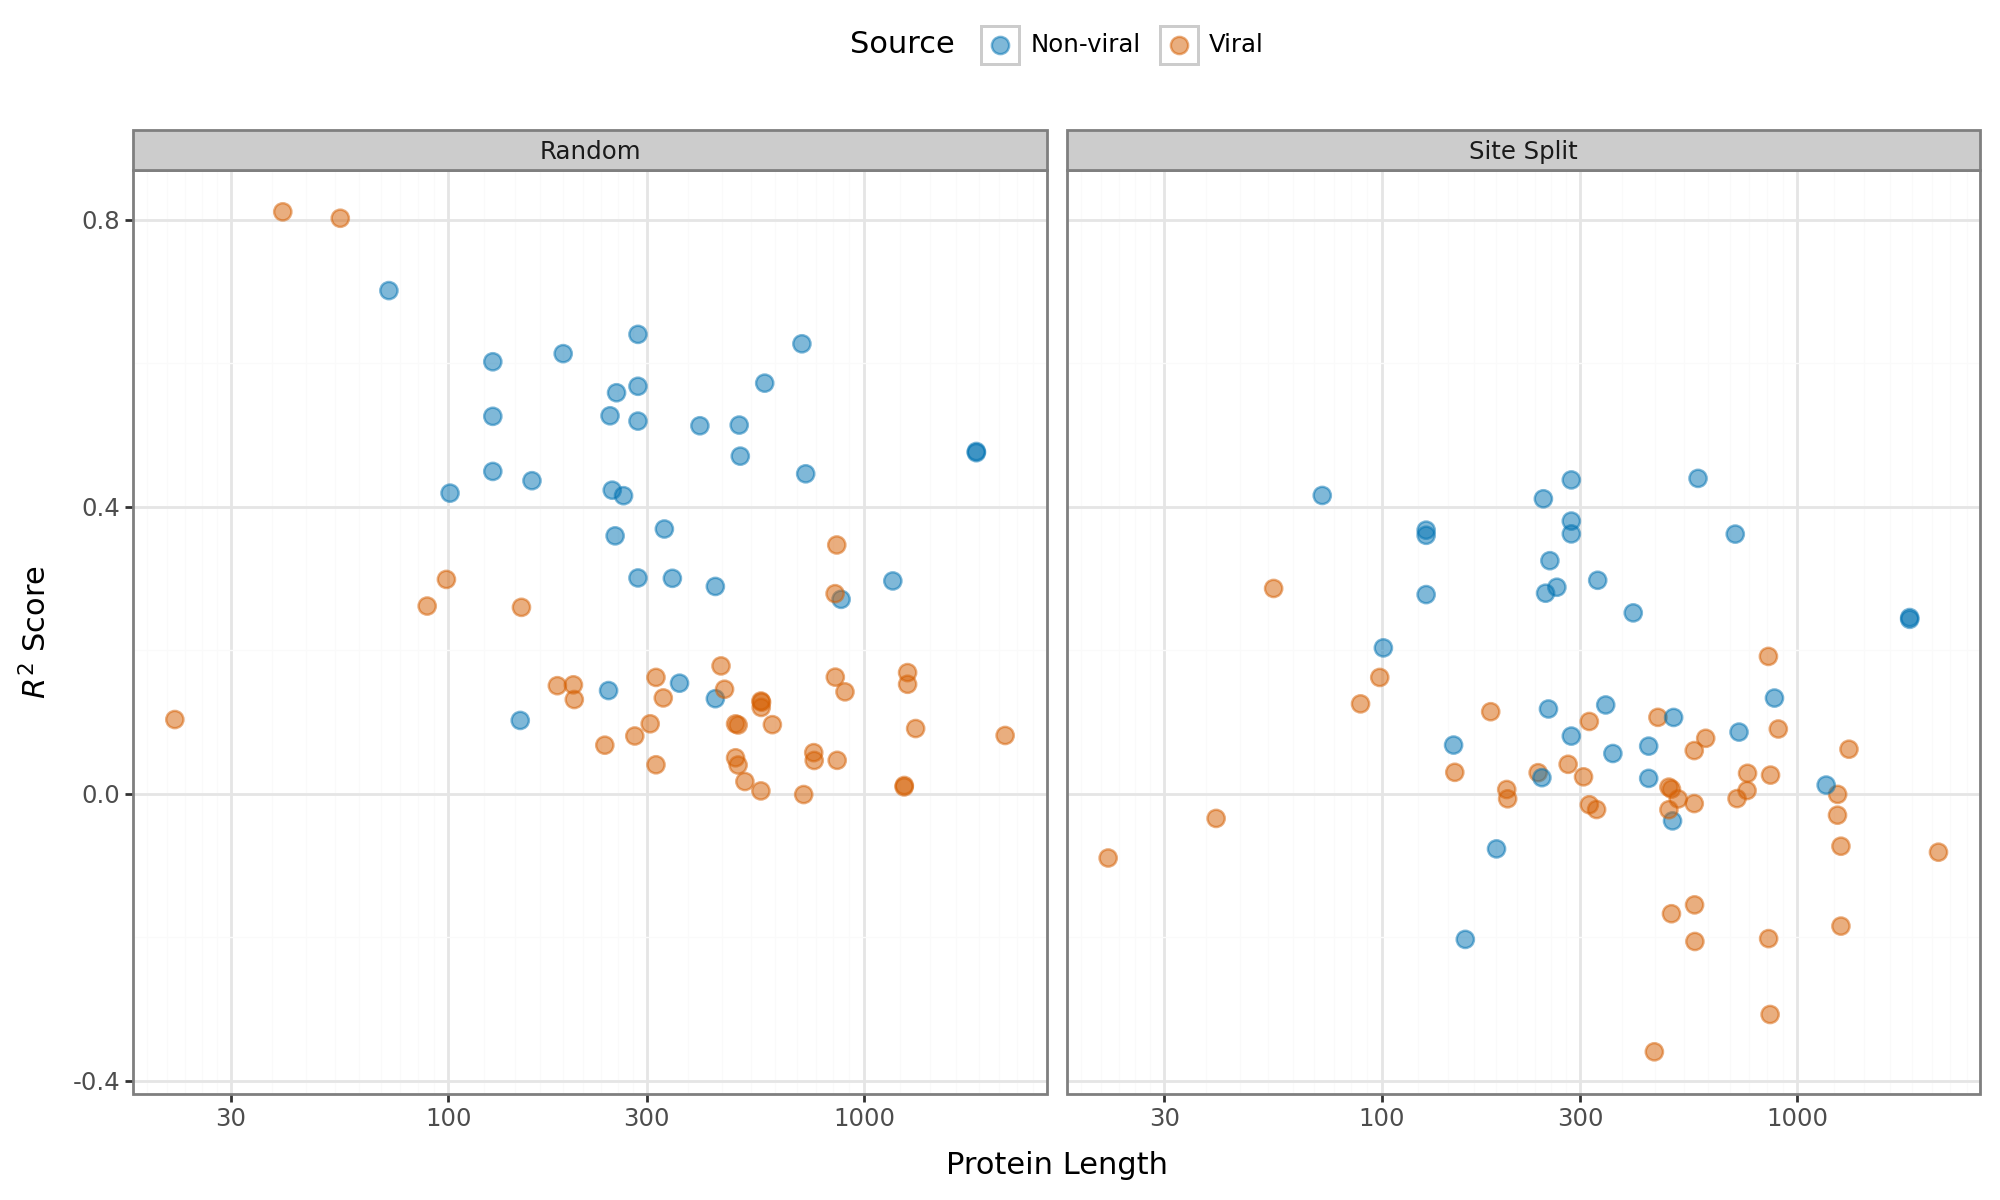

In [8]:
plot = (
    pln.ggplot(res_full, pln.aes(x='prot_length', y='R2_score_test'))
    + pln.geom_point(pln.aes(color='Source'), size=3, alpha=0.5)
    + pln.scale_color_manual(values={"Viral": "#D55E00", "Non-viral": "#0072B2"})
    + pln.facet_wrap('split_method')
    + pln.scale_x_log10()
    + pln.labs(x="Protein Length", y="$R^2$ Score")
    + pln.theme_bw()
    + pln.theme(figure_size=(10, 6), legend_position='top',)
    #+ pln.ylim(-0.2, 0.8)

)
plot#.save(filename='../experiments/protein_length_vs_lassocv_r2_full.png', dpi=600)

In [10]:
res_pivot = res_full.pivot_table(index=['dataset', 'Source'], columns='split_method', values='R2_score_test').reset_index()
res_pivot.to_csv('../experiments/viral_nonviral_splits_lassoCV_results.csv')

In [ ]:
plot = (
    pln.ggplot(res_pivot, pln.aes(y='Random', x='Site Split'))
    + pln.geom_point(pln.aes(color='Source'), size=3, alpha=0.5)
    + pln.geom_abline(slope=1, intercept=0, linetype='dashed', color='grey')
    + pln.scale_color_manual(values={"Viral": "#D55E00", "Non-viral": "#0072B2"})
    + pln.labs(y="Random", x="Site Split")
    + pln.theme_bw()
    + pln.theme(figure_size=(8, 6), legend_position='top',)
    + pln.ylim(-0.45, 1)
    + pln.xlim(-0.45, 1)

)
plot#.save(filename='../experiments/random_x_SS_lassocv_r2_full.png', dpi=600)

/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 8 x 6 in image.
/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ../experiments/random_x_SS_lassocv_r2_full.png


## non-viral x viral 

In [ ]:
plot = (
    pln.ggplot(res_full, pln.aes(x='Source', y='R2_score_test'))
    + pln.geom_boxplot(outlier_size=0.5, outlier_alpha=0.3, width=0.5)
    + pln.labs(
        x='Source',
        y='$R^2$',
    )
    + pln.theme_bw()
    + pln.theme(
        figure_size=(10, 5.5),
        panel_grid_major_x=pln.element_blank(),
    )
    + pln.facet_wrap('split_method', ncol=2)
)

plot#.save(filename='../experiments/sup1_lassocv_source_splits_r2_full.png', dpi=600)

/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 5.5 in image.
/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ../experiments/lassocv_source_splits_r2_full.png


# Fine tuned models

In [ ]:
# res_full = pd.DataFrame()
# for method in ['lassoCV', 'lassoCV_SS']:
  
#     res_dir_path = f'../experiments/lassoCV/esmc_600m/viral/{method}/'
#     res_esmc = read_results(res_dir_path, 'esmc_600m')

#     res_dir_path = f'../experiments/lassoCV/esm2_650m/viral/{method}'
#     res_esm2 = read_results(res_dir_path, 'esm2_650m')

#     res_dir_path = f'../experiments/lassoCV/esm2_viral_650m/viral/{method}'
#     res_esm2_viral = read_results(res_dir_path, 'esm2_viral_650m')

#     # res_dir_path = f'../experiments/lassoCV/rsawhney_esm2_3B/viral/{method}'
#     # res_rsawhney = read_results(res_dir_path, 'rsawhney_esm2_3B')


#     res = pd.concat([res_esmc, res_esm2, res_esm2_viral, res_rsawhney, ], ignore_index=True)
#     #res = pd.concat([res_esmc, ViCam_300m_full], ignore_index=True)
#     if method == 'lassoCV':
#         res['split_method'] = 'Pool'
#     elif method == 'lassoCV_SS':
#         res['split_method'] = 'Site Stratified'
#     res_full = pd.concat([res_full, res], ignore_index=True)

# res_full

In [157]:
cols = ['Model', 'Fold', 'R2_score_train', 'MAE_score_train',
       'RMSE_score_train', 'R2_score_test', 'MAE_score_test',
       'RMSE_score_test', 'rho_score_train', 'rho_score_test',
       'num_zero_coefs', 'Dataset', 'Source', 'Split']


res_dir_path = f'../experiments/lassoCV/esm2_viral_650m/viral/pool_split'
res_pool = read_results(res_dir_path, 'esm2_viral_650m_MP40')
res_pool.rename(columns={'nun_zero_coefs':'num_zero_coefs', 'dataset':'Dataset'}, inplace=True)
res_pool['Source'] = 'viral'
res_pool['Split'] = 'pooled'
res_pool = res_pool[cols] 


res_dir_path = f'../experiments/lassoCV/esm2_viral_650m/viral/site_split'
res_site = read_results(res_dir_path, 'esm2_viral_650m_MP40')
res_site.rename(columns={'dataset':'Dataset'}, inplace=True)
res_site['Source'] = 'viral'
res_site['Split'] = 'site'
res_site = res_site[cols] 
res_site = res_site.query('Fold < 4')
res_site

res_esm2_viral = pd.concat([res_pool, res_site])
res_esm2_viral

,Model,Fold,R2_score_train,MAE_score_train,RMSE_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_train,rho_score_test,num_zero_coefs,Dataset,Source,Split
0,esm2_viral_650m_MP40,1,0.247330,0.551299,0.874218,0.244077,0.576051,0.842162,0.565873,0.538255,192,IAV_PB2_Soh,viral,pooled
1,esm2_viral_650m_MP40,2,0.260572,0.551910,0.871223,0.243437,0.559786,0.822414,0.570824,0.541236,203,IAV_PB2_Soh,viral,pooled
2,esm2_viral_650m_MP40,3,0.246588,0.559875,0.873172,0.253784,0.545034,0.842740,0.563439,0.564531,198,IAV_PB2_Soh,viral,pooled
3,esm2_viral_650m_MP40,1,0.110219,0.367538,0.861171,0.036722,0.405160,1.266332,0.409821,0.393931,146,SARS2_DELTA_SPIKE_Dadonaite,viral,pooled
4,esm2_viral_650m_MP40,2,0.076692,0.390929,0.985180,0.050329,0.375643,0.868846,0.387788,0.372682,93,SARS2_DELTA_SPIKE_Dadonaite,viral,pooled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,esm2_viral_650m_MP40,2,0.169012,0.727411,0.913659,0.146322,0.723833,0.914976,0.434503,0.393066,58,IAV_H1_NP_Doud,viral,site
197,esm2_viral_650m_MP40,3,0.180003,0.719194,0.905618,0.115850,0.741467,0.939397,0.449782,0.355948,55,IAV_H1_NP_Doud,viral,site
200,esm2_viral_650m_MP40,1,0.228693,0.741465,0.881325,0.184854,0.751968,0.889885,0.472516,0.423738,167,EV_REP_Bakhache,viral,site
201,esm2_viral_650m_MP40,2,0.234966,0.733484,0.873103,0.178205,0.761787,0.911399,0.477902,0.419869,165,EV_REP_Bakhache,viral,site


In [160]:
models = ["esmc_600m", "esm2_650m"]
full_res = pd.read_csv('../experiments/lassoCV/results_4models_3folds_v_nv_SS_P.csv', index_col=0)
#full_res = full_res.query('Model in @models')
full_res = full_res.query('Model != "rsawhney_esm2_3B"')
full_res = full_res[cols]
full_res = full_res.query('Fold < 4')
full_res

,Model,Fold,R2_score_train,MAE_score_train,RMSE_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_train,rho_score_test,num_zero_coefs,Dataset,Source,Split
0,esm2_650m,1,0.293028,0.636302,0.863418,-0.076546,0.661374,0.916954,0.414383,0.146640,40,SARS2_PRD0038_RBD_Starr,viral,site
1,esm2_650m,2,0.185222,0.674901,0.914246,0.168593,0.656686,0.863289,0.337174,0.302062,15,SARS2_PRD0038_RBD_Starr,viral,site
2,esm2_650m,3,0.156070,0.684361,0.914523,0.109362,0.700166,0.959868,0.297714,0.352247,17,SARS2_PRD0038_RBD_Starr,viral,site
3,esm2_650m,1,0.270192,0.705873,0.858758,0.247014,0.694528,0.847557,0.564320,0.532887,66,IAV_H3_HA_Lee,viral,site
4,esm2_650m,2,0.219202,0.729762,0.883830,0.172357,0.744978,0.906407,0.509140,0.459610,25,IAV_H3_HA_Lee,viral,site
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1327,esmc_600m,2,0.497856,0.540401,0.706903,0.388097,0.602123,0.789129,0.717548,0.608746,84,SUMO1_HUMAN_Roth2017,nonviral,pooled
1328,esmc_600m,3,0.492267,0.540774,0.709310,0.380991,0.605999,0.797862,0.709468,0.623976,74,SUMO1_HUMAN_Roth2017,nonviral,pooled
1329,esmc_600m,1,0.519848,0.535507,0.693293,0.451171,0.560300,0.739269,0.770983,0.729294,202,KKA2_KLEPN_Mikkelsen2014,nonviral,pooled
1330,esmc_600m,2,0.507750,0.541418,0.702754,0.485021,0.546000,0.712860,0.768475,0.737995,191,KKA2_KLEPN_Mikkelsen2014,nonviral,pooled


In [161]:
res_rsawhney = pd.read_csv('../experiments/lassoCV/res_esm2rsawhney_v_SS_P.csv', index_col=0)
res_rsawhney = res_rsawhney[cols]
res_rsawhney

,Model,Fold,R2_score_train,MAE_score_train,RMSE_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_train,rho_score_test,num_zero_coefs,Dataset,Source,Split
0,rsawhney_esm2_3B,1,0.006420,0.430784,1.048536,0.014956,0.399608,0.751975,0.069929,0.114450,7,SARS2_DELTA_SPIKE_Dadonaite,viral,site
1,rsawhney_esm2_3B,2,0.009685,0.412588,0.977049,0.005952,0.438590,1.066018,0.082114,0.071014,8,SARS2_DELTA_SPIKE_Dadonaite,viral,site
2,rsawhney_esm2_3B,3,0.010054,0.413982,1.007572,0.010290,0.428900,0.942637,0.085559,0.097281,14,SARS2_DELTA_SPIKE_Dadonaite,viral,site
3,rsawhney_esm2_3B,1,0.039474,0.848686,0.973045,0.012358,0.898219,1.016208,0.191746,0.124886,11,CVB3_VP1_Alvarez,viral,site
4,rsawhney_esm2_3B,2,0.036550,0.893743,0.998819,0.000139,0.829900,0.918722,0.186855,0.152385,9,CVB3_VP1_Alvarez,viral,site
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,rsawhney_esm2_3B,2,0.735490,0.393086,0.516234,0.462174,0.530430,0.722027,0.725208,0.627647,649,SARS2_XBB15_RBD_Taylor,viral,pooled
242,rsawhney_esm2_3B,3,0.620455,0.472480,0.615580,0.458251,0.561859,0.738298,0.663095,0.594820,403,SARS2_XBB15_RBD_Taylor,viral,pooled
243,rsawhney_esm2_3B,1,0.754997,0.390583,0.494536,0.606804,0.505156,0.629255,0.791973,0.753587,678,CVB3_3C_Alvarez,viral,pooled
244,rsawhney_esm2_3B,2,0.729530,0.409551,0.518258,0.585188,0.516906,0.652913,0.788580,0.712339,560,CVB3_3C_Alvarez,viral,pooled


In [162]:
res_full = pd.concat([full_res, res_rsawhney, res_esm2_viral])
res_full = res_full.query('Source == "viral"') 
res_full

,Model,Fold,R2_score_train,MAE_score_train,RMSE_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_train,rho_score_test,num_zero_coefs,Dataset,Source,Split
0,esm2_650m,1,0.293028,0.636302,0.863418,-0.076546,0.661374,0.916954,0.414383,0.146640,40,SARS2_PRD0038_RBD_Starr,viral,site
1,esm2_650m,2,0.185222,0.674901,0.914246,0.168593,0.656686,0.863289,0.337174,0.302062,15,SARS2_PRD0038_RBD_Starr,viral,site
2,esm2_650m,3,0.156070,0.684361,0.914523,0.109362,0.700166,0.959868,0.297714,0.352247,17,SARS2_PRD0038_RBD_Starr,viral,site
3,esm2_650m,1,0.270192,0.705873,0.858758,0.247014,0.694528,0.847557,0.564320,0.532887,66,IAV_H3_HA_Lee,viral,site
4,esm2_650m,2,0.219202,0.729762,0.883830,0.172357,0.744978,0.906407,0.509140,0.459610,25,IAV_H3_HA_Lee,viral,site
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,esm2_viral_650m_MP40,2,0.169012,0.727411,0.913659,0.146322,0.723833,0.914976,0.434503,0.393066,58,IAV_H1_NP_Doud,viral,site
197,esm2_viral_650m_MP40,3,0.180003,0.719194,0.905618,0.115850,0.741467,0.939397,0.449782,0.355948,55,IAV_H1_NP_Doud,viral,site
200,esm2_viral_650m_MP40,1,0.228693,0.741465,0.881325,0.184854,0.751968,0.889885,0.472516,0.423738,167,EV_REP_Bakhache,viral,site
201,esm2_viral_650m_MP40,2,0.234966,0.733484,0.873103,0.178205,0.761787,0.911399,0.477902,0.419869,165,EV_REP_Bakhache,viral,site


In [163]:
cols=['rho_score_test', 'R2_score_test', 'rho_score_train', 'R2_score_train']
res_full = res_full.groupby(['Dataset', 'Model', 'Split'], as_index=False)[cols].mean()
res_full 

,Dataset,Model,Split,rho_score_test,R2_score_test,rho_score_train,R2_score_train
0,BPP22_COAT_Tsuboyama,esm2_650m,pooled,0.869235,0.809457,0.937024,0.904862
1,BPP22_COAT_Tsuboyama,esm2_650m,site,0.703125,0.517028,0.905805,0.828914
2,BPP22_COAT_Tsuboyama,esm2_viral_650m,pooled,0.846675,0.778986,0.947090,0.939017
3,BPP22_COAT_Tsuboyama,esm2_viral_650m,site,0.405745,0.134322,0.841047,0.759077
4,BPP22_COAT_Tsuboyama,esm2_viral_650m_MP40,pooled,0.846029,0.799695,0.925801,0.907111
...,...,...,...,...,...,...,...
405,SARS2_XBB15_RBD_Taylor,esm2_viral_650m_MP40,site,0.351436,0.077452,0.465878,0.238409
406,SARS2_XBB15_RBD_Taylor,esmc_600m,pooled,0.524755,0.327754,0.586639,0.459899
407,SARS2_XBB15_RBD_Taylor,esmc_600m,site,0.264043,0.054705,0.373054,0.206807
408,SARS2_XBB15_RBD_Taylor,rsawhney_esm2_3B,pooled,0.615989,0.463961,0.699893,0.694630


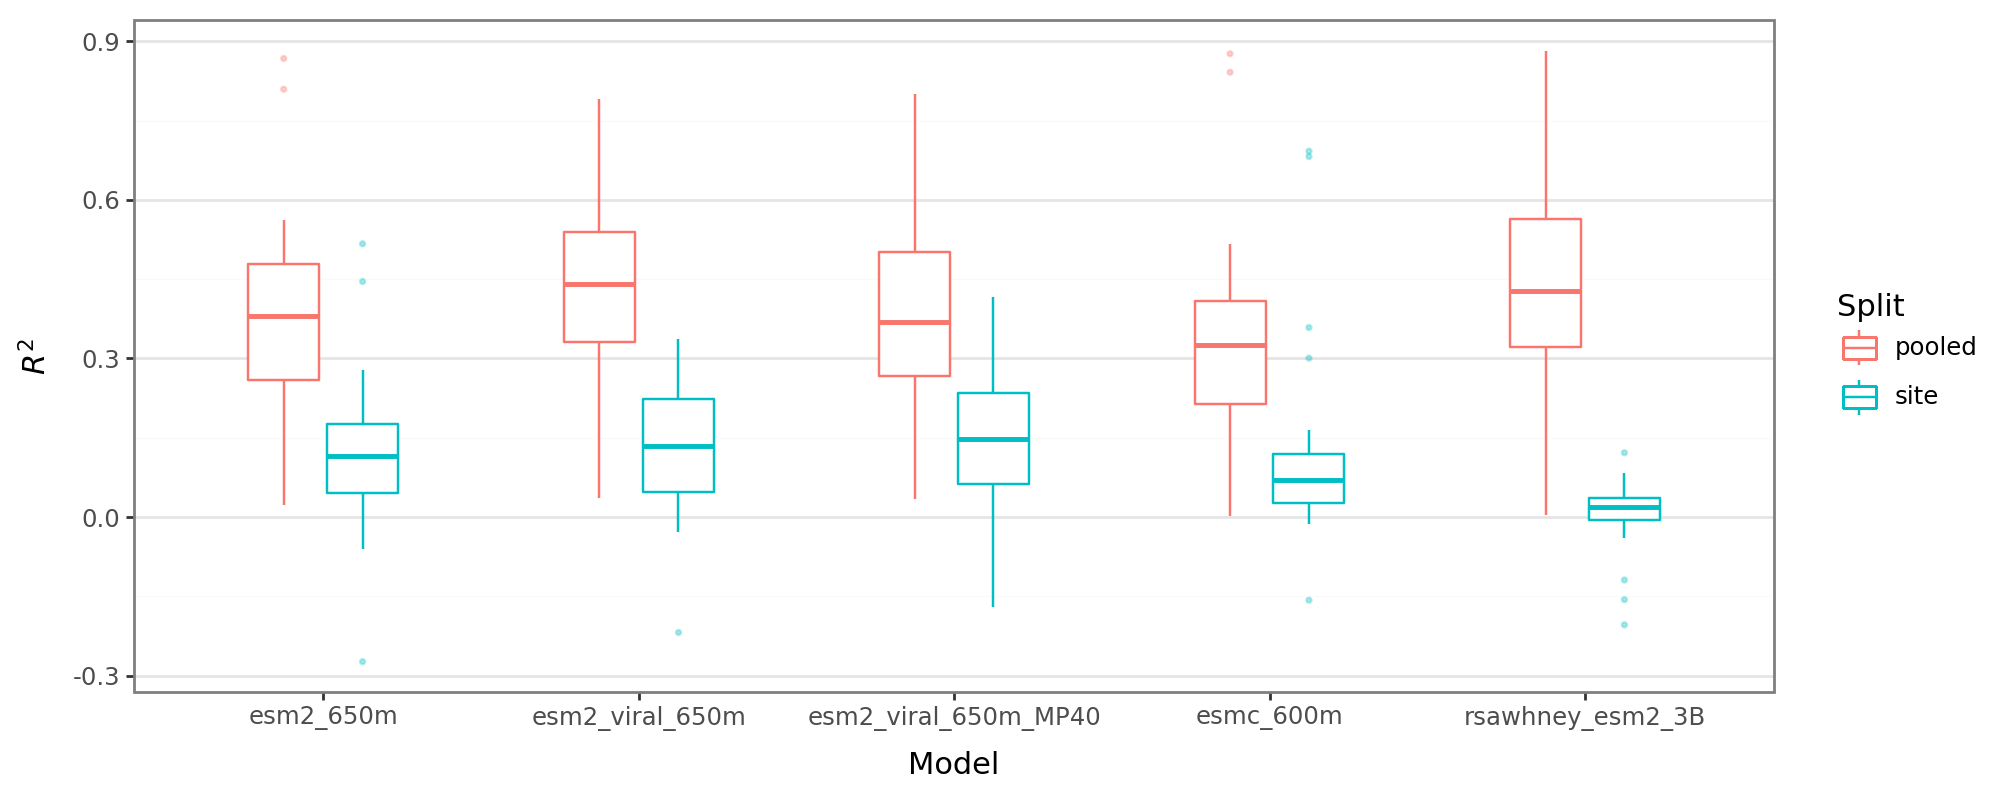

In [165]:
plot = (
    pln.ggplot(res_full, pln.aes(x='Model', y='R2_score_test', color='Split'))
    + pln.geom_boxplot(outlier_size=0.5, outlier_alpha=0.3, width=0.5)
    #+ pln.scale_color_manual(values={"viral": "#D55E00", "nonviral": "#0072B2"})
    + pln.labs(
        x='Model',
        y='$R^2$',
    )
    + pln.theme_bw()
    + pln.theme(
        figure_size=(10, 4),
        panel_grid_major_x=pln.element_blank(),
    )
)

plot

In [46]:
#res_pivot = res_full.query('split_method == "K-fold"').pivot_table(index=['dataset'], columns='Model', values='R2_score_test').reset_index()
res_pivot = res_full.pivot_table(index=['dataset','split_method' ], columns='Model', values='R2_score_test').reset_index()
res_pivot['Lab'] = res_pivot['dataset'].apply(lambda x: x.split('_')[-1])
res_pivot.dropna(axis=0)

Model,dataset,split_method,esm2_650m,esm2_viral_650m,esmc_600m,rsawhney_esm2_3B,Lab
0,BPP22_COAT_Tsuboyama,Pool,0.771564,0.665831,0.843465,0.289438,Tsuboyama
1,BPP22_COAT_Tsuboyama,Site Stratified,0.288731,0.205157,0.453531,-0.722636,Tsuboyama
2,CVB3_2A_Alvarez,Pool,0.383874,0.345171,0.338303,0.090679,Alvarez
3,CVB3_2A_Alvarez,Site Stratified,-0.091176,0.013652,-0.098717,0.006071,Alvarez
4,CVB3_2B_Alvarez,Pool,0.352400,0.329042,0.125694,0.079787,Alvarez
...,...,...,...,...,...,...,...
77,SARS2_RBD_binding_Starr,Site Stratified,0.040556,-0.069971,-0.056752,-0.007102,Starr
78,SARS2_RBD_expression_Starr,Pool,0.100039,0.345994,0.206226,0.017981,Starr
79,SARS2_RBD_expression_Starr,Site Stratified,0.033159,-0.119332,0.036755,-0.015359,Starr
80,SARS2_XBB15_RBD_Taylor,Pool,0.173852,0.360817,0.145804,0.034174,Taylor


/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:372: PlotnineWarning: geom_point : Removed 15 rows containing missing values.


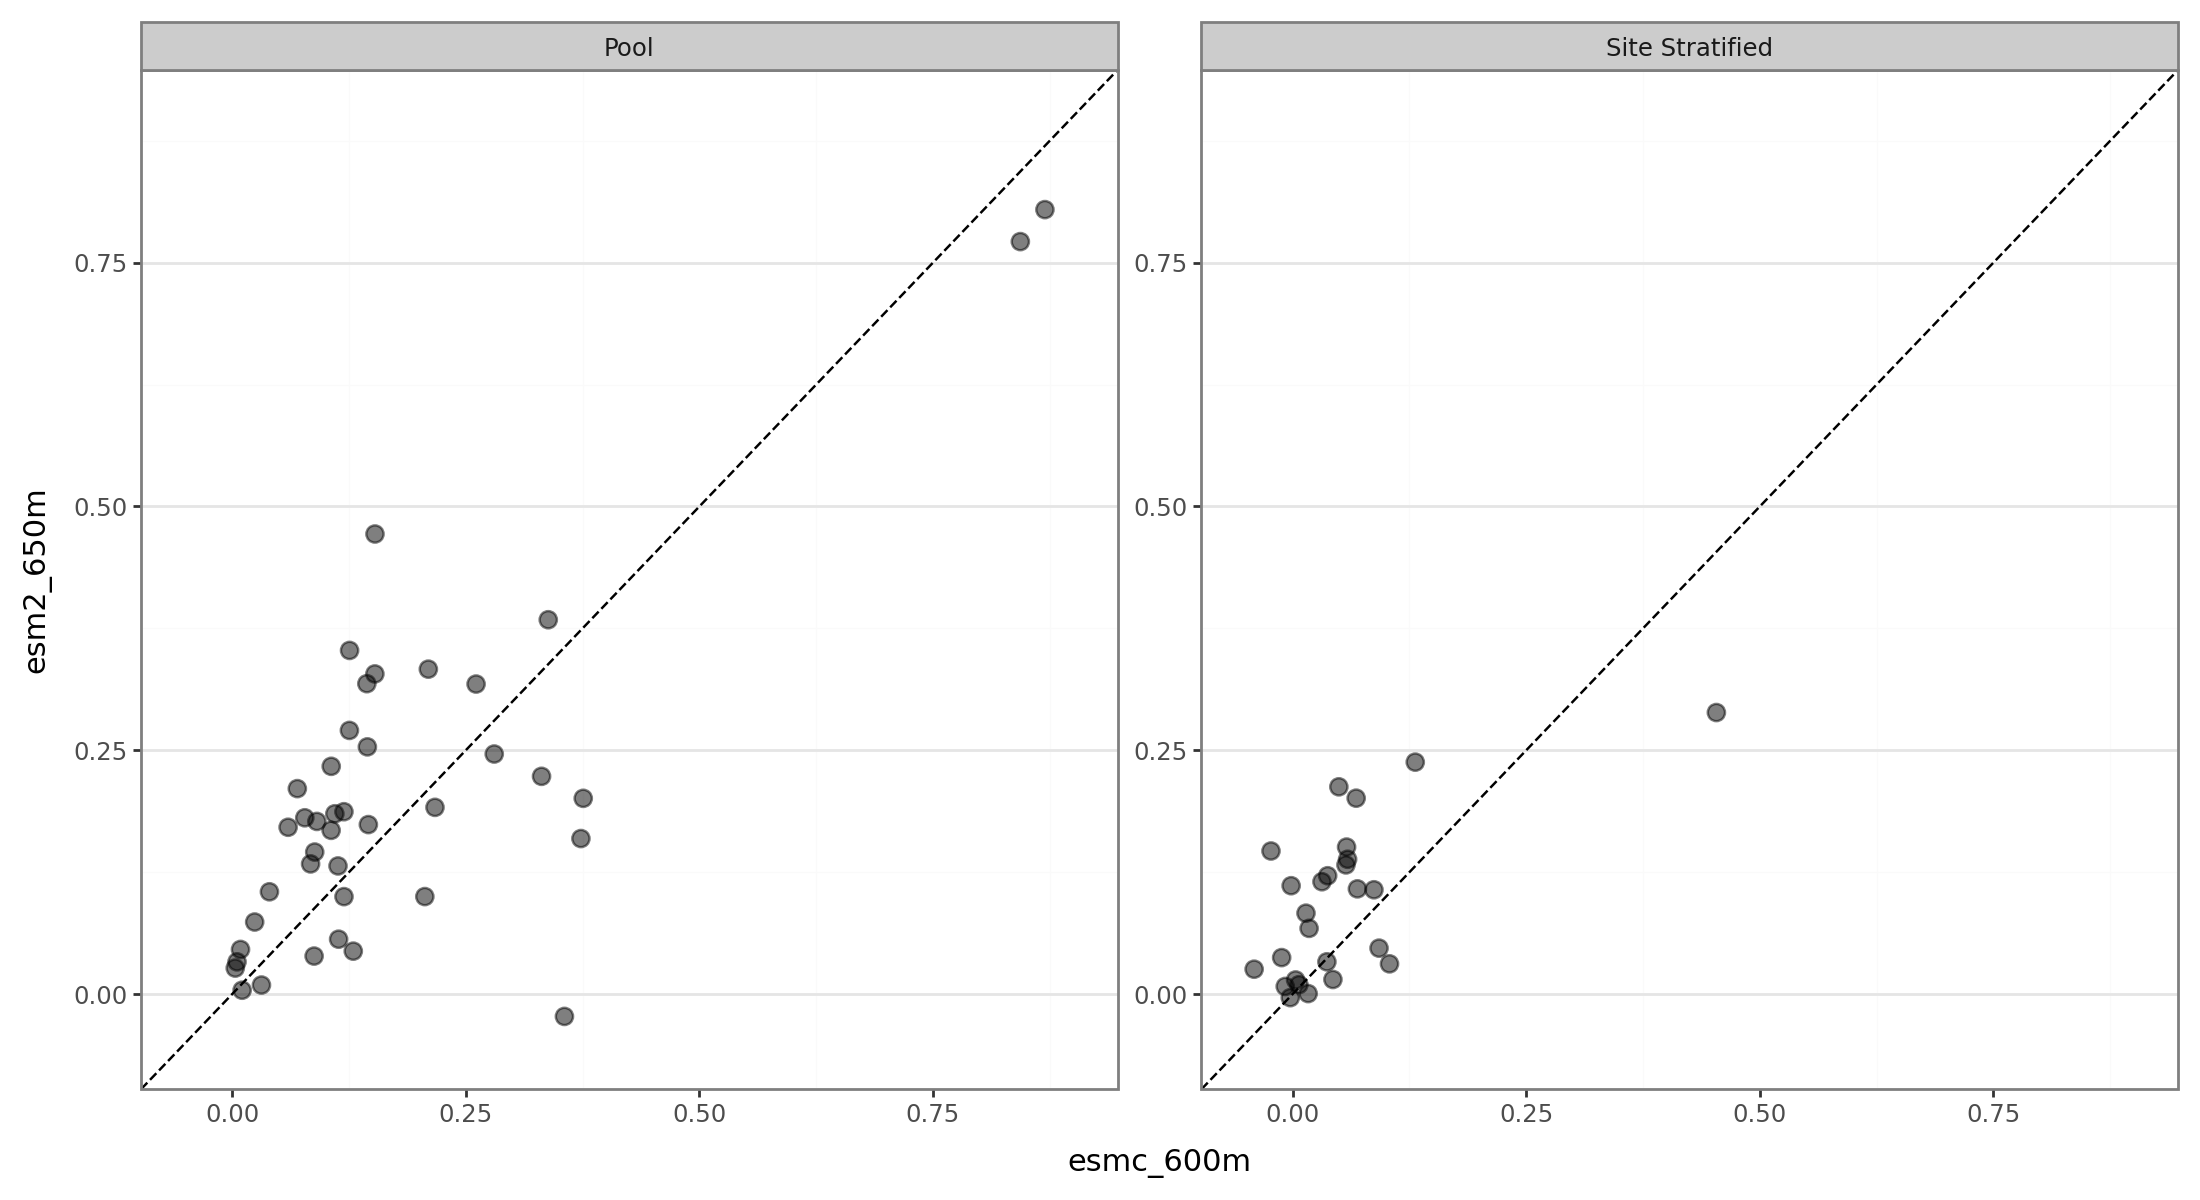

In [47]:
plot = (
    pln.ggplot(res_pivot, pln.aes(x='esmc_600m', y='esm2_650m'))
    + pln.geom_point(pln.aes(), size=3, alpha=0.5)
    + pln.geom_abline(intercept=0, slope=1, linetype='dashed', color='black')  # 1:1 line
    + pln.theme_bw()
    + pln.theme(
        panel_grid_major_x=pln.element_blank(),
        figure_size=(11, 6),
    )
    + pln.facet_wrap('split_method', ncol=2, scales='free_y')
    + pln.labs(
        y='esm2_650m',
        x='esmc_600m',
    )
    + pln.ylim(-0.05, .9)
    + pln.xlim(-0.05, .9)
)

plot#.save(filename='../experiments/res_esm2_650m_x_esmc_600m.png', dpi=600)

/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:372: PlotnineWarning: geom_point : Removed 4 rows containing missing values.


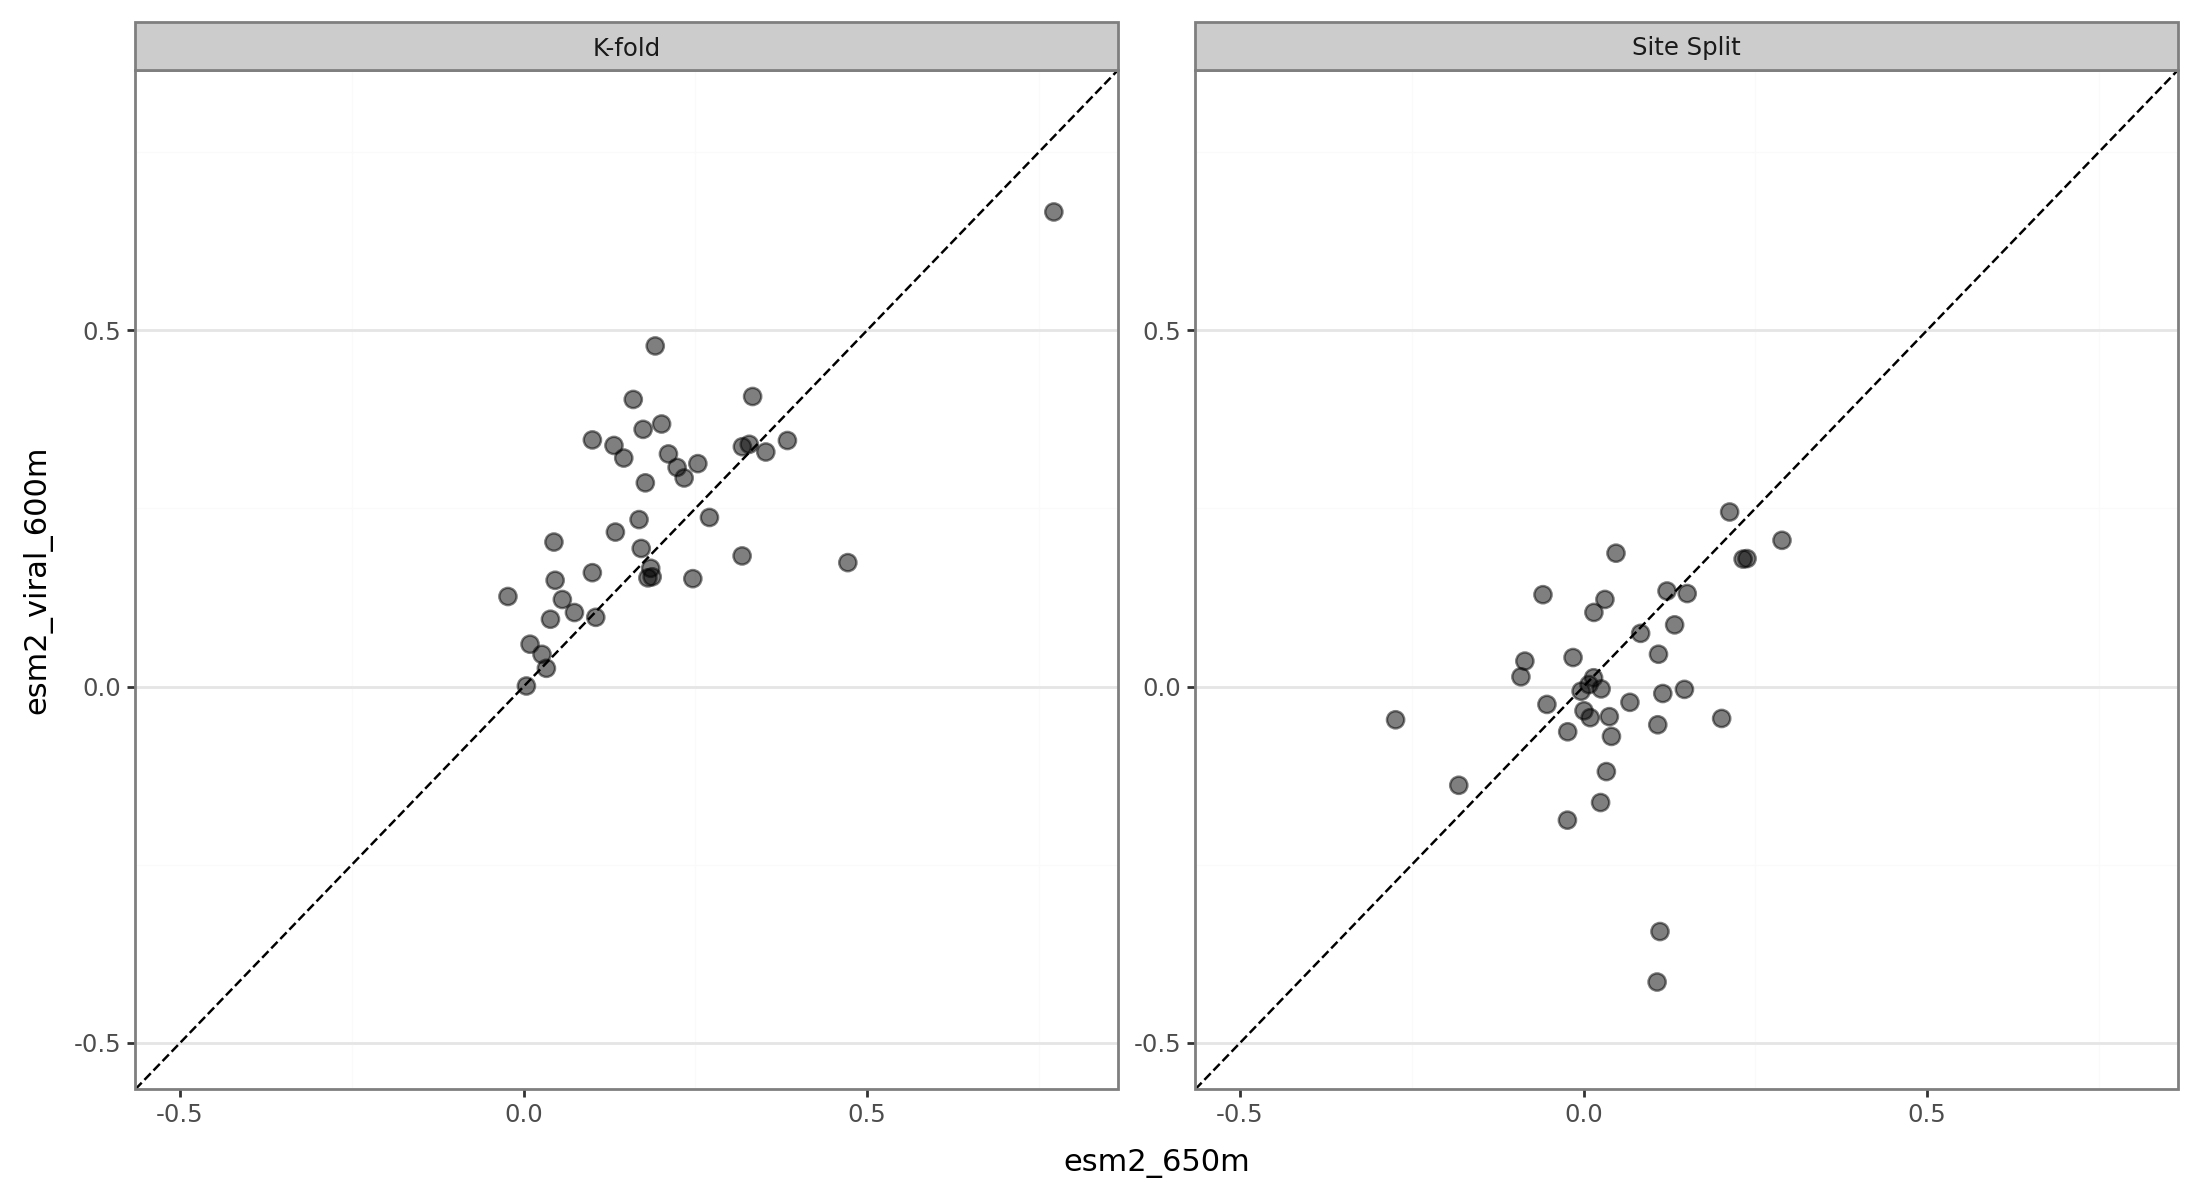

In [43]:
plot = (
    pln.ggplot(res_pivot, pln.aes(y='esm2_viral_650m', x='esm2_650m'))
    + pln.geom_point(pln.aes(), size=3, alpha=0.5)
    + pln.geom_abline(intercept=0, slope=1, linetype='dashed', color='black')  # 1:1 line
    + pln.theme_bw()
    + pln.theme(
        panel_grid_major_x=pln.element_blank(),
        figure_size=(11, 6),
    )
    + pln.facet_wrap('split_method', ncol=2, scales='free_y')
    + pln.labs(
        x='esm2_650m',
        y='esm2_viral_600m',
    )
    + pln.ylim(-0.5, .8)
    + pln.xlim(-0.5, .8)
)

plot

In [9]:
# plot = (
#     pln.ggplot(res_pivot, pln.aes(x='esmc_300m', y='ViCam_300m'))
#     + pln.geom_point(pln.aes(color='Lab'), size=3, alpha=0.5)
#     + pln.geom_abline(intercept=0, slope=1, linetype='dashed', color='black')  # 1:1 line
#     + pln.theme_bw()
#     + pln.theme(
#         panel_grid_major_x=pln.element_blank(),
#         figure_size=(9, 6),
#     )
#     + pln.labs(
#         y='ViCam_300m',
#         x='esmc_300m',
#     )
#     + pln.ylim(-0.05, .5)
#     + pln.xlim(-0.05, .5)
# )

# plot#.save(filename='../experiments/res_vicam_x_esmc_300m.png', dpi=600)

In [ ]:
res_full['Model'] = pd.Categorical(res_full['Model'], 
                                    categories=['ViCam_300m', 'esmc_300m', 'rsawhney_esm2_3B'])


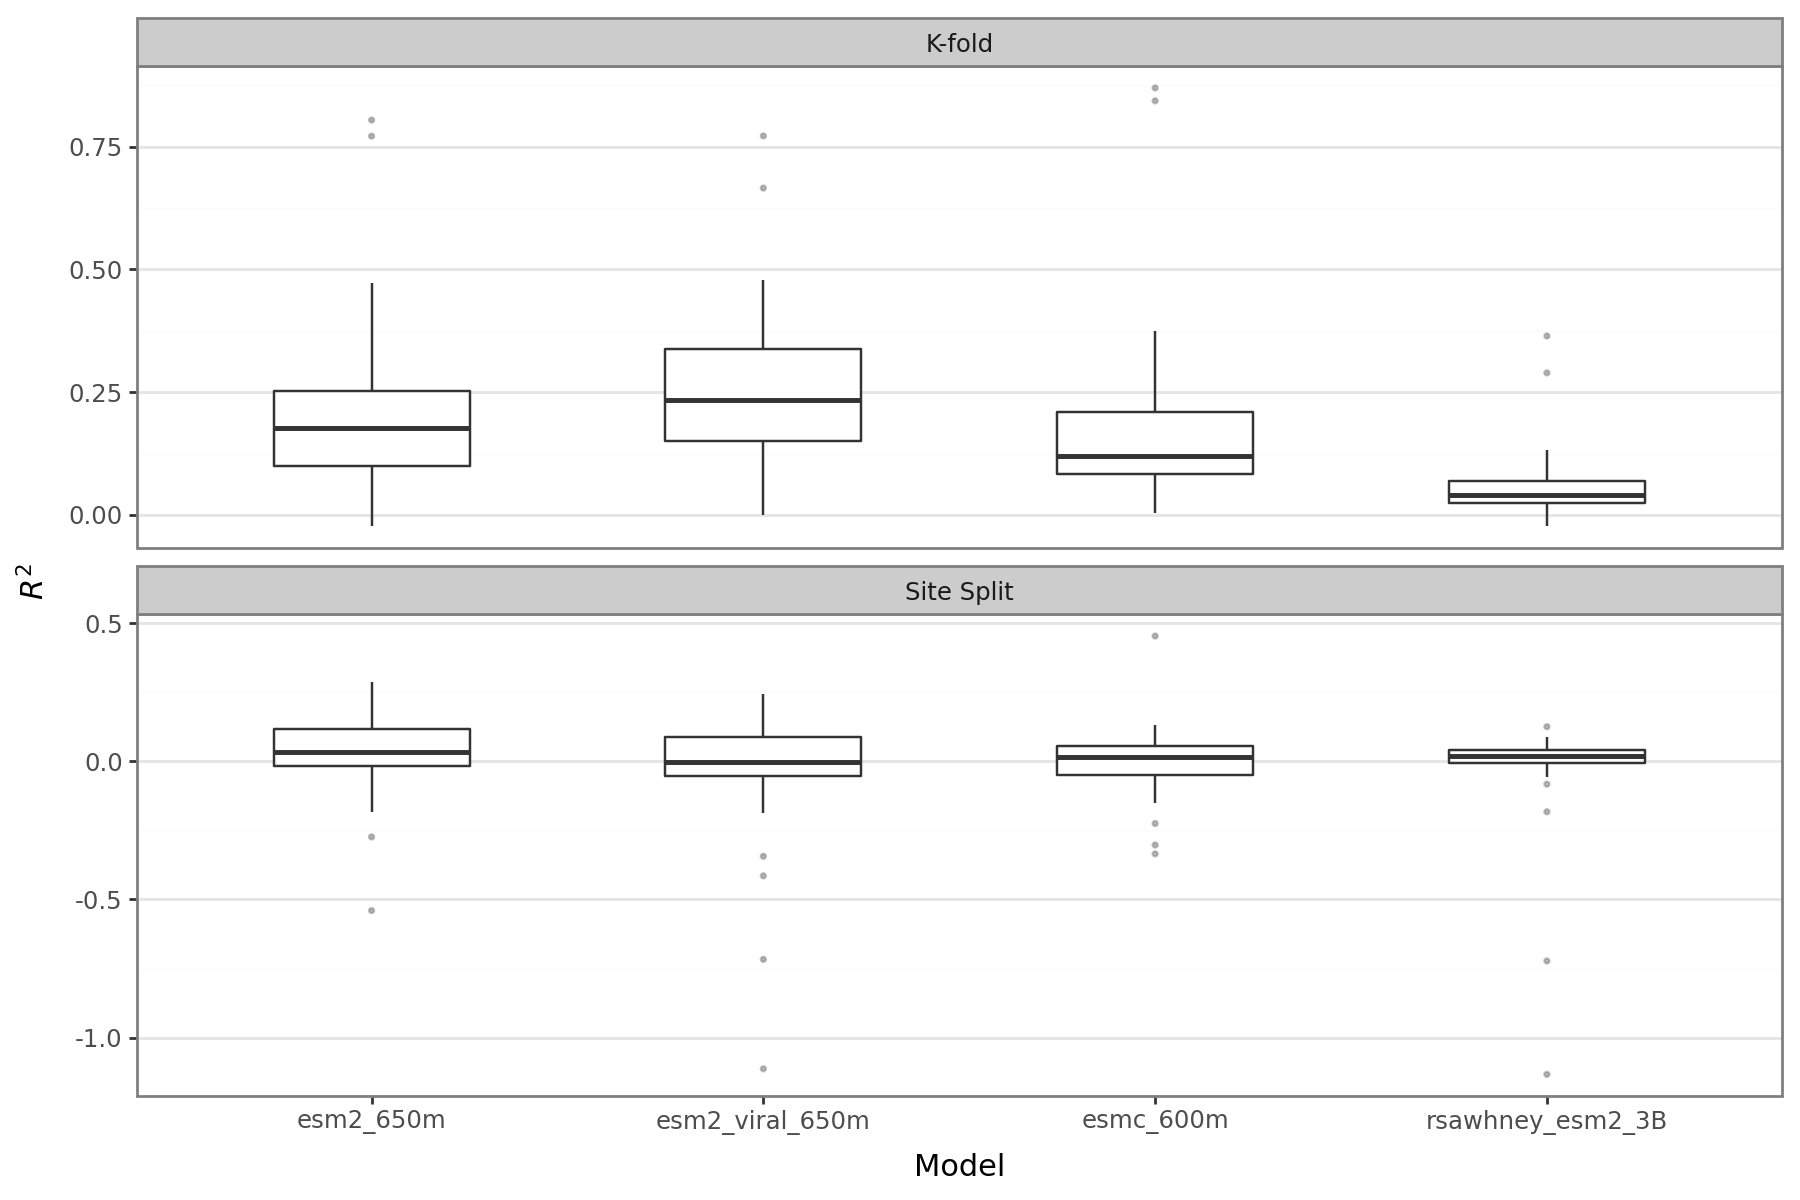

In [22]:
plot = (
    pln.ggplot(res_full, pln.aes(x='Model', y='R2_score_test'))
    + pln.geom_boxplot(outlier_size=0.5, outlier_alpha=0.3, width=0.5)
    + pln.theme_bw()
    + pln.theme(
        panel_grid_major_x=pln.element_blank(),
        figure_size=(9, 6),
    )
    + pln.labs(
        x='Model',
        y='$R^2$',
    )
    #+ pln.ylim(-0.2, .9)
    + pln.facet_wrap('split_method', nrow=2, scales='free_y')
)


plot#.save(filename='../experiments/res_finetuned_models_r2.png', dpi=600)

# Lasso results all models

In [1]:
import pandas as pd
import plotnine as pln

In [13]:
res = pd.read_csv('../experiments_v01/lassoCV/results_4models_3folds_v_nv_SS_P.csv', index_col=0)
res['Model'] = pd.Categorical(res['Model'], categories=['esmc_600m', 'esm2_650m', 'esm2_viral_650m', 'rsawhney_esm2_3B'], ordered=True)
res

,Fold,R2_score_train,MAE_score_train,RMSE_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_train,rho_score_test,num_zero_coefs,Dataset,Dataset_Size,Prot_Length,Model,Source,Split
0,1,0.293028,0.636302,0.863418,-0.076546,0.661374,0.916954,0.414383,0.146640,40,SARS2_PRD0038_RBD_Starr,3998,200,esm2_650m,viral,site
1,2,0.185222,0.674901,0.914246,0.168593,0.656686,0.863289,0.337174,0.302062,15,SARS2_PRD0038_RBD_Starr,3998,200,esm2_650m,viral,site
2,3,0.156070,0.684361,0.914523,0.109362,0.700166,0.959868,0.297714,0.352247,17,SARS2_PRD0038_RBD_Starr,3998,200,esm2_650m,viral,site
3,1,0.270192,0.705873,0.858758,0.247014,0.694528,0.847557,0.564320,0.532887,66,IAV_H3_HA_Lee,10754,566,esm2_650m,viral,site
4,2,0.219202,0.729762,0.883830,0.172357,0.744978,0.906407,0.509140,0.459610,25,IAV_H3_HA_Lee,10754,566,esm2_650m,viral,site
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1771,2,0.697654,0.432616,0.552728,0.524055,0.529136,0.675303,0.814520,0.711667,611,PTEN_HUMAN_Fowler2018,4229,403,rsawhney_esm2_3B,nonviral,pooled
1772,3,0.691392,0.427804,0.550186,0.553494,0.540224,0.692383,0.815477,0.727172,607,PTEN_HUMAN_Fowler2018,4229,403,rsawhney_esm2_3B,nonviral,pooled
1773,1,0.790112,0.344433,0.459803,0.496030,0.523168,0.699376,0.835496,0.670760,283,RL401_YEAST_Fraser2016,1324,128,rsawhney_esm2_3B,nonviral,pooled
1774,2,0.717256,0.395203,0.526315,0.614182,0.476788,0.643454,0.799535,0.741660,221,RL401_YEAST_Fraser2016,1324,128,rsawhney_esm2_3B,nonviral,pooled


In [14]:
ols = pd.read_csv('../experiments_v01/lassoCV/results_OLS_3folds_v_nv_Pooled.csv', index_col=0)
ols

,Model,Fold,R2_score_train,MAE_score_train,RMSE_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_train,rho_score_test,Dataset,Source,Split
0,OLS,1,0.376406,0.628156,0.792004,0.304368,0.658004,0.824147,0.598880,0.540495,IAV_H1_NP_Doud,viral,pooled
1,OLS,2,0.379339,0.625441,0.787427,0.290447,0.672475,0.844004,0.601615,0.526581,IAV_H1_NP_Doud,viral,pooled
2,OLS,3,0.378776,0.625165,0.787603,0.300951,0.671381,0.838504,0.600995,0.533578,IAV_H1_NP_Doud,viral,pooled
0,OLS,1,0.348981,0.343840,0.762675,0.203165,0.379728,0.641082,0.639177,0.371428,IAV_H1_HA_Wu,viral,pooled
1,OLS,2,0.389340,0.328689,0.711756,-0.026567,0.398681,0.890459,0.630545,0.419289,IAV_H1_HA_Wu,viral,pooled
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,OLS,2,0.137988,0.731342,0.926392,-0.026640,0.798818,1.022744,0.368474,0.140475,CALM1_HUMAN_Roth2017,nonviral,pooled
2,OLS,3,0.141814,0.734375,0.932268,-0.024135,0.785742,0.986381,0.369130,0.177240,CALM1_HUMAN_Roth2017,nonviral,pooled
0,OLS,1,0.509198,0.412195,0.684900,0.448029,0.479561,0.804435,0.718037,0.682826,IF1_ECOLI,nonviral,pooled
1,OLS,2,0.490962,0.425552,0.704523,0.502878,0.454994,0.738491,0.720461,0.700028,IF1_ECOLI,nonviral,pooled


In [ ]:
cols = ols.columns
res = res[cols].copy()

In [32]:
full_res = pd.concat([res, ols])
full_res = full_res.query('Split == "pooled"')
full_res

,Model,Fold,R2_score_train,MAE_score_train,RMSE_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_train,rho_score_test,Dataset,Source,Split
222,esm2_650m,1,0.497957,0.358033,0.706846,0.334259,0.409826,0.823566,0.387404,0.331674,RsYN04_RBD_Starr,viral,pooled
223,esm2_650m,2,0.514225,0.351044,0.680006,0.364114,0.421413,0.870540,0.398480,0.336159,RsYN04_RBD_Starr,viral,pooled
224,esm2_650m,3,0.552944,0.343720,0.666253,0.012415,0.460961,1.007469,0.425952,0.254701,RsYN04_RBD_Starr,viral,pooled
225,esm2_650m,1,0.533833,0.545635,0.684939,0.451785,0.582998,0.730235,0.678964,0.593596,NIPAH_F_Larsen,viral,pooled
226,esm2_650m,2,0.532209,0.544980,0.685028,0.462241,0.580267,0.728672,0.670414,0.623268,NIPAH_F_Larsen,viral,pooled
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,OLS,2,0.137988,0.731342,0.926392,-0.026640,0.798818,1.022744,0.368474,0.140475,CALM1_HUMAN_Roth2017,nonviral,pooled
2,OLS,3,0.141814,0.734375,0.932268,-0.024135,0.785742,0.986381,0.369130,0.177240,CALM1_HUMAN_Roth2017,nonviral,pooled
0,OLS,1,0.509198,0.412195,0.684900,0.448029,0.479561,0.804435,0.718037,0.682826,IF1_ECOLI,nonviral,pooled
1,OLS,2,0.490962,0.425552,0.704523,0.502878,0.454994,0.738491,0.720461,0.700028,IF1_ECOLI,nonviral,pooled


In [33]:
full_res['Model'] = pd.Categorical(full_res['Model'], ordered=True, categories=['OLS', 'esm2_viral_650m', 'rsawhney_esm2_3B', 'esm2_650m', 'esmc_600m', 
       ])

In [34]:
df_mean = full_res.groupby(['Source', 'Dataset', 'Model'], as_index=False)['R2_score_test'].mean()
df_mean 

/tmp/ipykernel_1616683/1095277929.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,Source,Dataset,Model,R2_score_test
0,nonviral,AMIE_PSEAE_Whitehead,OLS,0.389637
1,nonviral,AMIE_PSEAE_Whitehead,esm2_viral_650m,0.407154
2,nonviral,AMIE_PSEAE_Whitehead,rsawhney_esm2_3B,0.567911
3,nonviral,AMIE_PSEAE_Whitehead,esm2_650m,0.488876
4,nonviral,AMIE_PSEAE_Whitehead,esmc_600m,0.471465
...,...,...,...,...
735,viral,YAP1_HUMAN_Fields2012_singles,OLS,NaN
736,viral,YAP1_HUMAN_Fields2012_singles,esm2_viral_650m,NaN
737,viral,YAP1_HUMAN_Fields2012_singles,rsawhney_esm2_3B,NaN
738,viral,YAP1_HUMAN_Fields2012_singles,esm2_650m,NaN


/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 370 rows containing non-finite values.


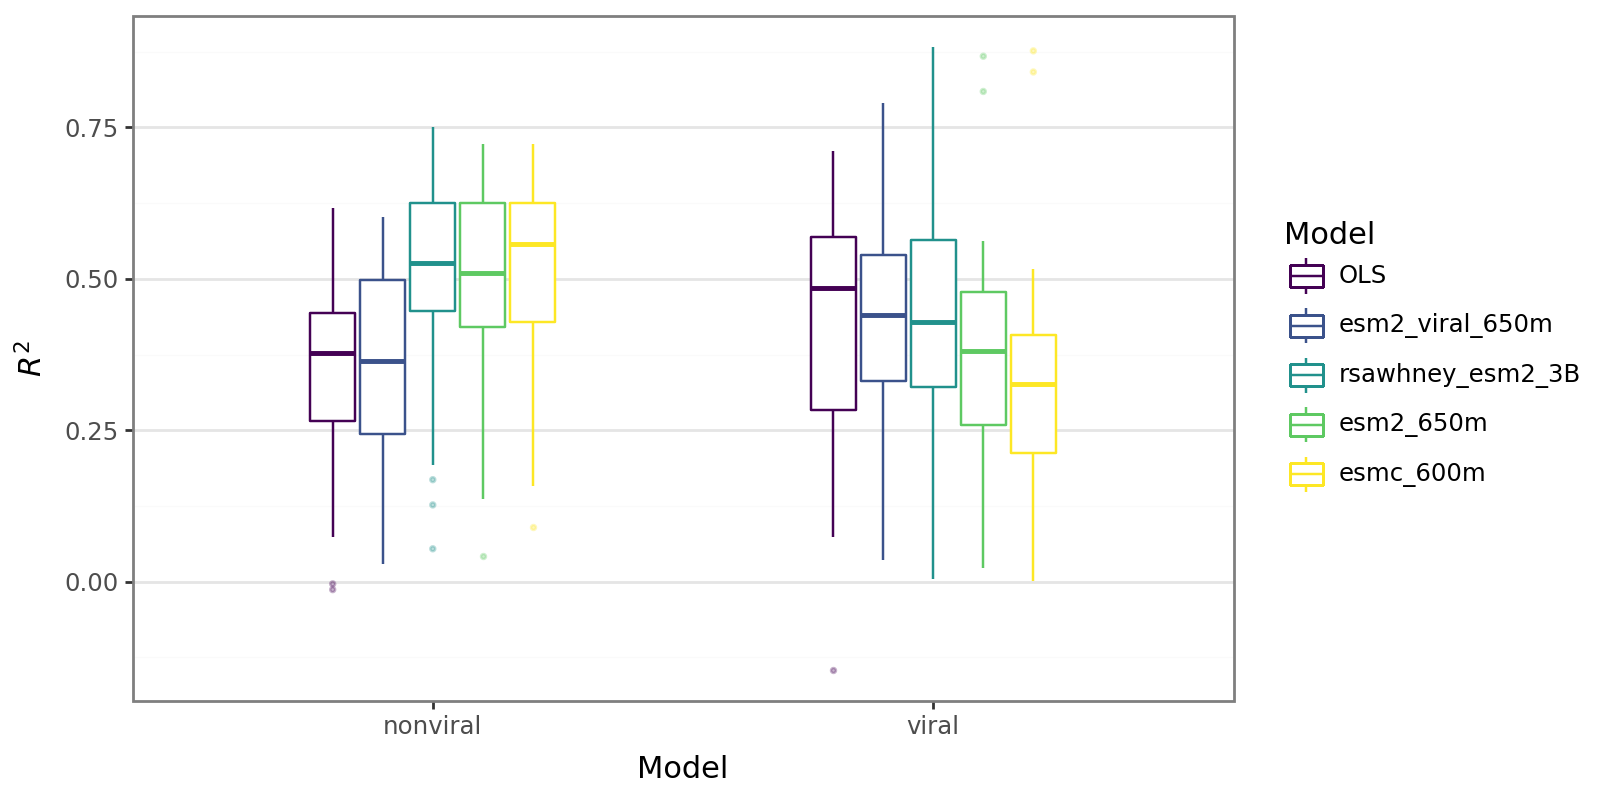

In [35]:
plot = (
    pln.ggplot(df_mean , pln.aes(x='Source', y='R2_score_test', color='Model'))
    + pln.geom_boxplot(outlier_size=0.5, outlier_alpha=0.3, width=0.5)
    #+ pln.scale_color_manual(values={"viral": "#D55E00", "nonviral": "#0072B2"})
    + pln.labs(
        x='Model',
        y='$R^2$',
    )
    + pln.theme_bw()
    + pln.theme(
        figure_size=(8, 4),
        panel_grid_major_x=pln.element_blank(),
    )
)

plot#.save(filename='../experiments/feature_extraction_SS_r2.png', dpi=600)

/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:372: PlotnineWarning: geom_point : Removed 165 rows containing missing values.


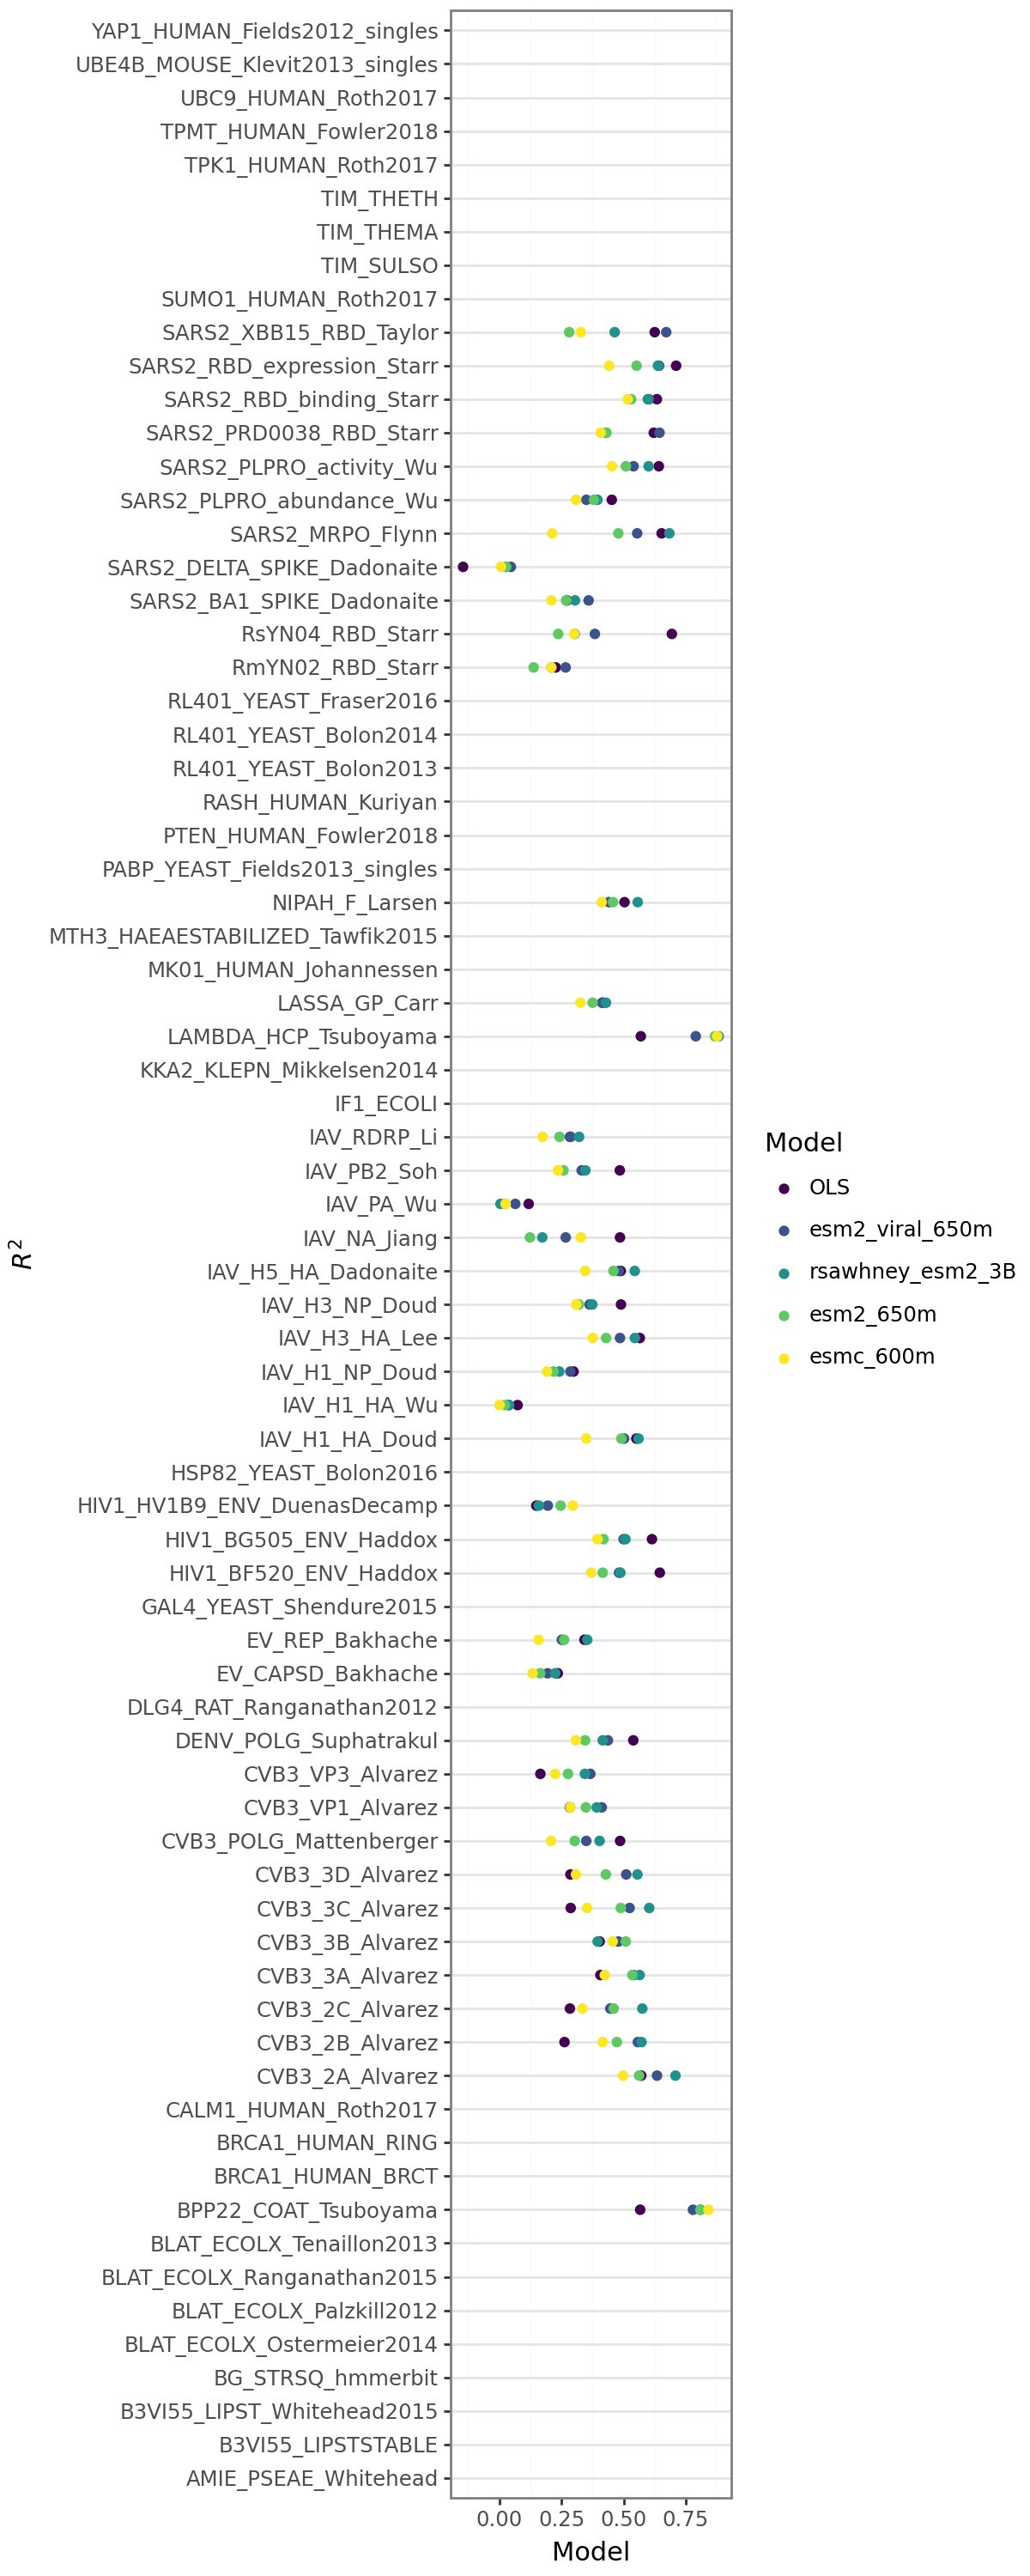

In [39]:
plot = (
    pln.ggplot(df_mean.query('Source =="viral"'), pln.aes(y='Dataset', x='R2_score_test', color='Model'))
    + pln.geom_point()
    + pln.labs(
        x='Model',
        y='$R^2$',
    )
    + pln.theme_bw()
    + pln.theme(
        figure_size=(6, 15),
        panel_grid_major_x=pln.element_blank(),
    )
    #+ pln.ylim(-0.2, .8)
)

plot#.save(filename='../experiments/feature_extraction_SS_r2.png', dpi=600)